In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from scipy.stats import boxcox 
from statsmodels.tsa.seasonal import STL
from utils import load_data, check_stationarity
from plots import *

# Load & Process Data

In [37]:
selected_data = load_data()

/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

## Plot time Series

In [38]:
selected_data

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_prec,lagged_tmed,lagged_tmax,lagged_tmin
date,,,,,,,,,,,,,
1995-01-01,1995-01-01,13.86,5.67,9.77,1,1995,144.1,8.19,2.102914,NaN,NaN,NaN,NaN
1995-02-01,1995-02-01,15.12,6.62,10.87,2,1995,92.8,8.50,2.140066,144.1,9.77,9.77,9.77
1995-03-01,1995-03-01,18.09,7.00,12.54,3,1995,31.3,11.09,2.406044,92.8,10.87,10.87,10.87
1995-04-01,1995-04-01,21.59,8.63,15.11,4,1995,30.5,12.96,2.561868,31.3,12.54,12.54,12.54
1995-05-01,1995-05-01,23.35,12.32,17.84,5,1995,51.4,11.03,2.400619,30.5,15.11,15.11,15.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-01,2019-09-01,28.00,13.90,20.95,9,2019,19.8,14.10,2.646175,16.2,22.53,22.53,22.53
2019-10-01,2019-10-01,22.42,11.08,16.75,10,2019,79.3,11.34,2.428336,19.8,20.95,20.95,20.95
2019-11-01,2019-11-01,15.71,8.53,12.12,11,2019,160.8,7.18,1.971299,79.3,16.75,16.75,16.75


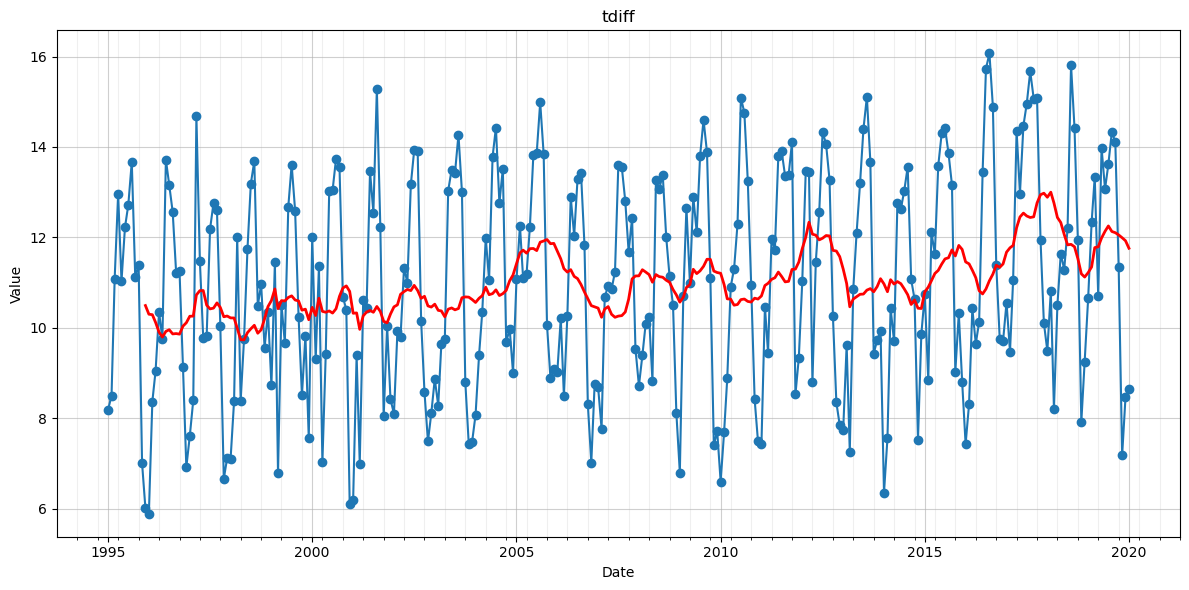

In [39]:
plot_time_series(selected_data, 'date', 'tdiff', ma_window=12)

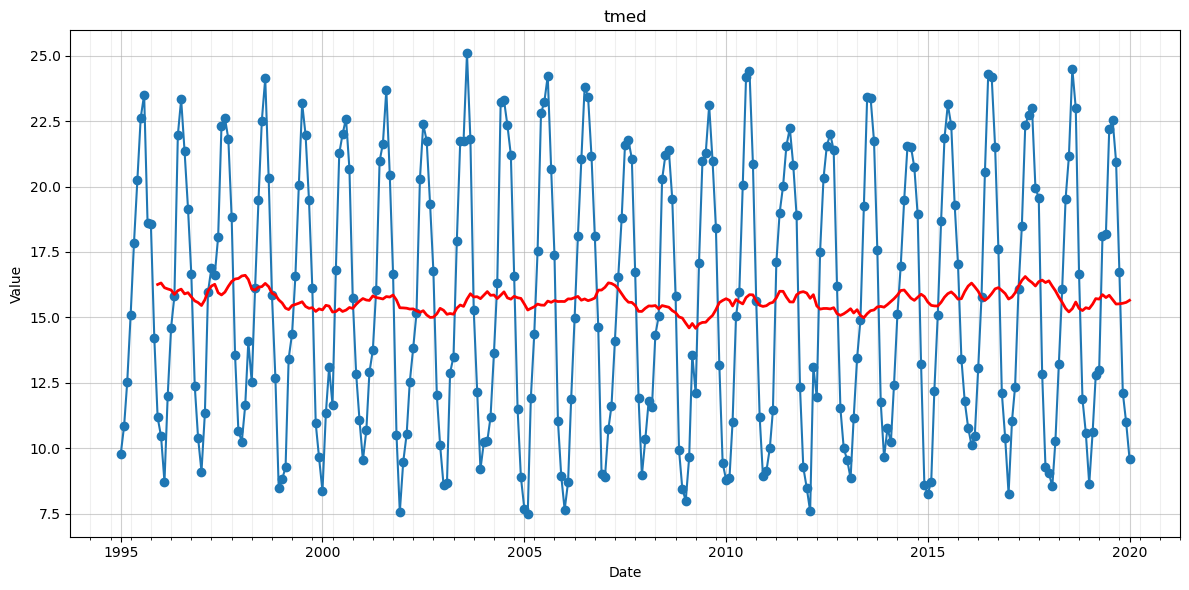

In [40]:
plot_time_series(selected_data, 'date', 'tmed', ma_window=12)

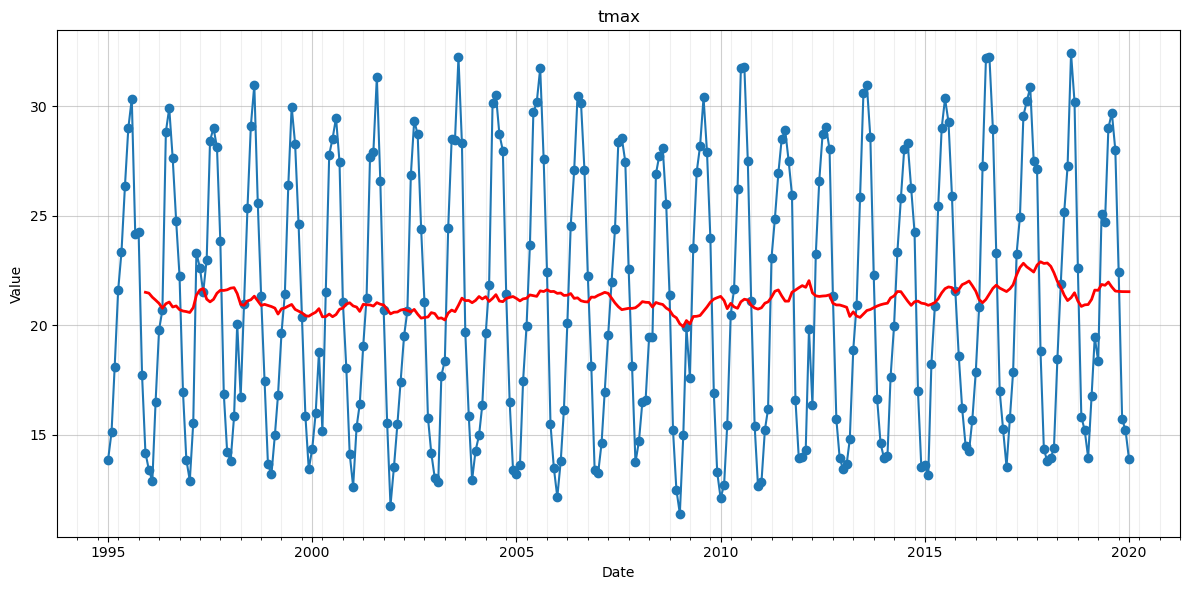

In [41]:
plot_time_series(selected_data, 'date', 'tmax', ma_window=12)

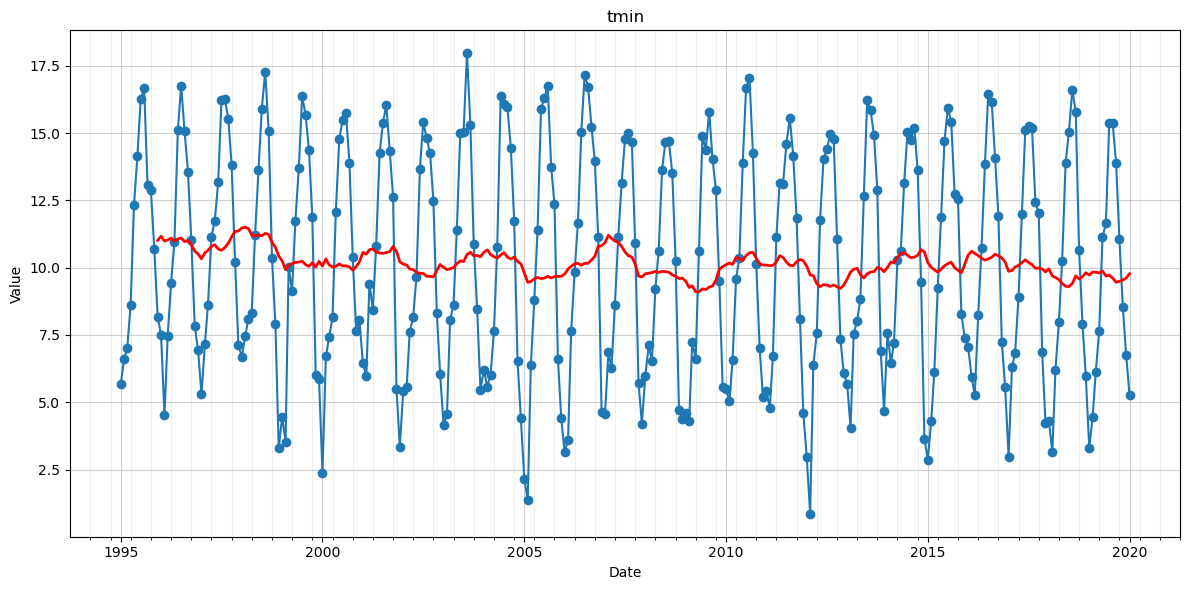

In [42]:
plot_time_series(selected_data, 'date', 'tmin', ma_window=12)

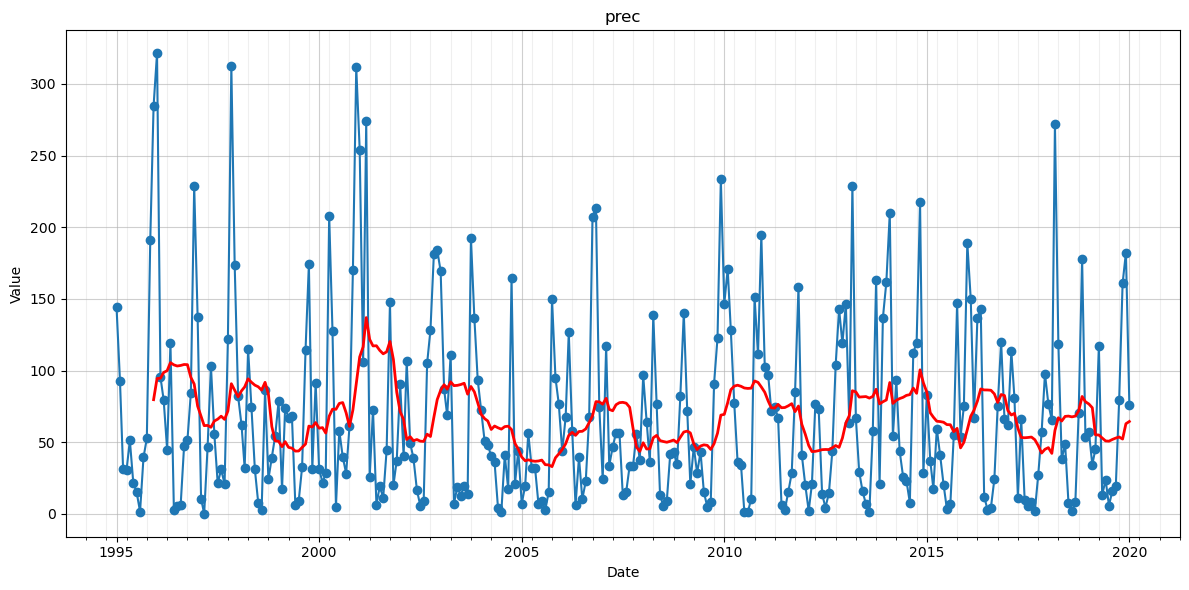

In [43]:
plot_time_series(selected_data, 'date', 'prec', ma_window=12)

### Log Feat

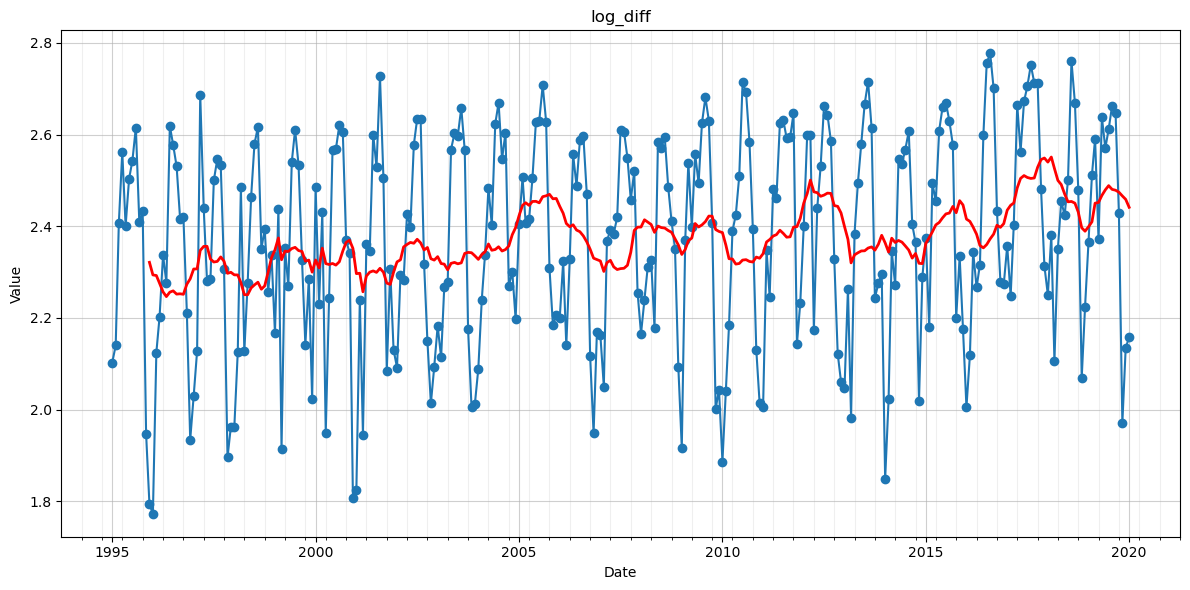

In [44]:
plot_time_series(selected_data, 'date', 'log_diff', ma_window=12)

## Seasonal Plot

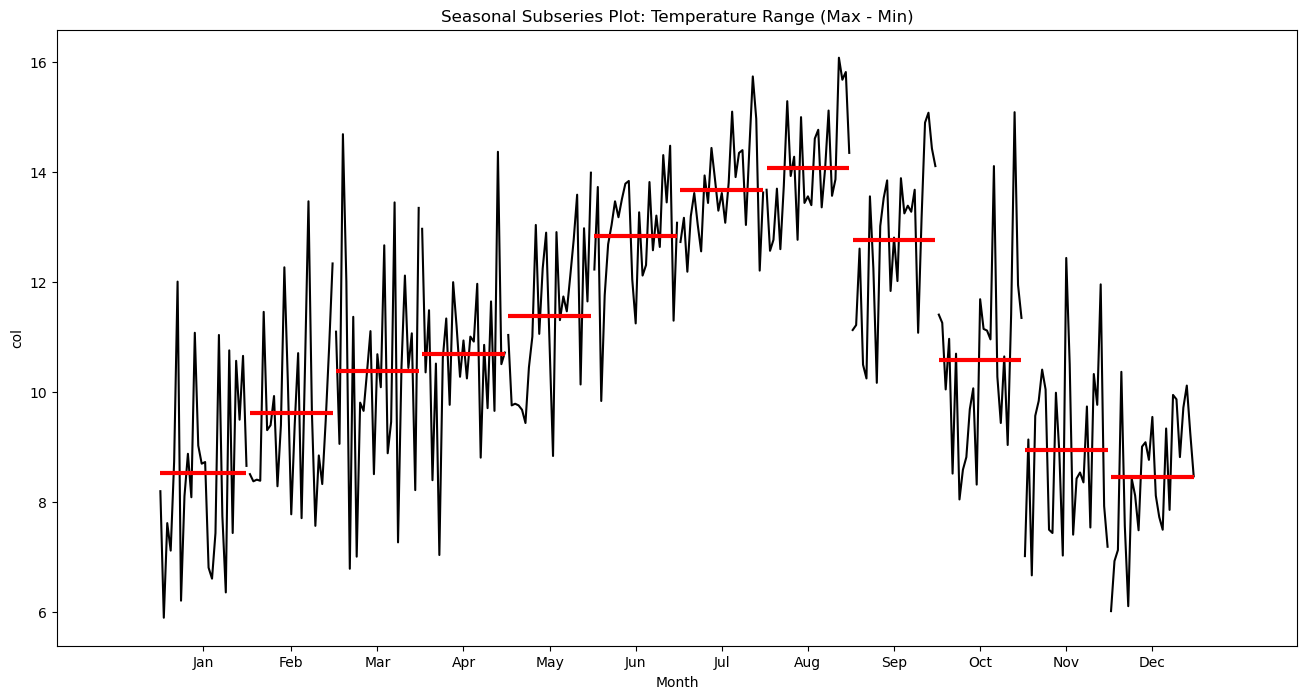

In [45]:
seasonal_plot(selected_data, 'tdiff', "Seasonal Subseries Plot: Temperature Range (Max - Min)")

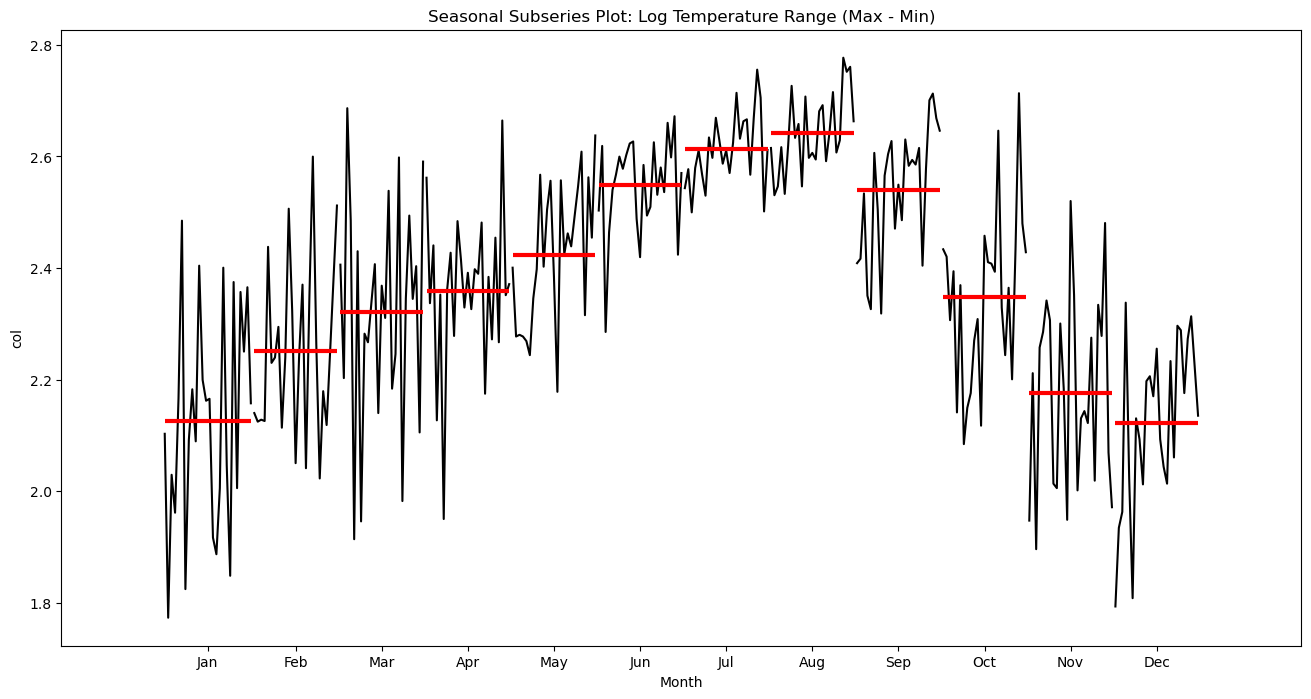

In [46]:
seasonal_plot(selected_data, 'log_diff', "Seasonal Subseries Plot: Log Temperature Range (Max - Min)")

## Box Cox

Estimated Lambda: 0.9456862893476805


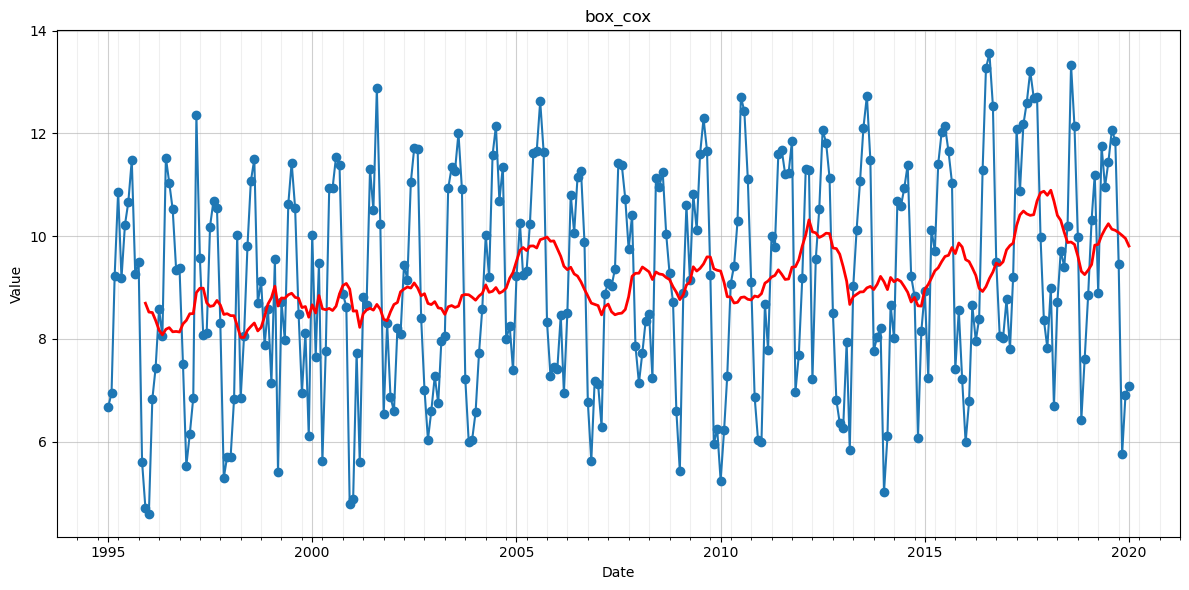

In [47]:
bc, lambda_ = boxcox(selected_data['tdiff'])
print(f"Estimated Lambda: {lambda_}")

plot_time_series(pd.DataFrame.from_dict({
    "date": list(selected_data.index),
    "box_cox": bc
}), 'date', 'box_cox', ma_window=12)

Estimated Lambda: 3.0209376577804172


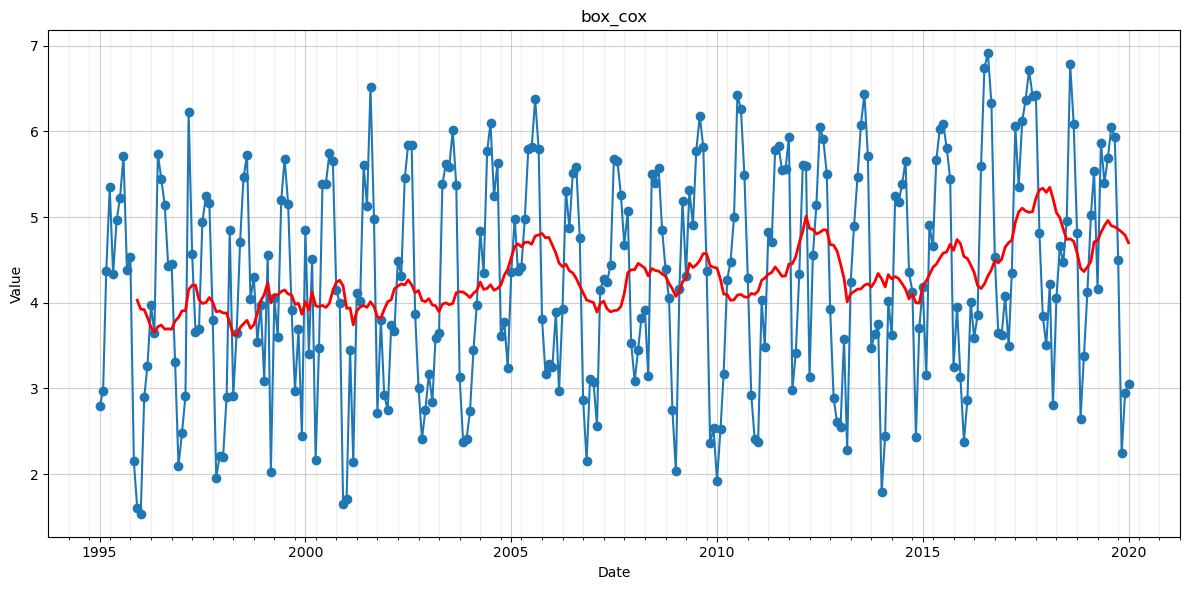

In [48]:
bc, lambda_ = boxcox(selected_data['log_diff'])
print(f"Estimated Lambda: {lambda_}")

plot_time_series(pd.DataFrame.from_dict({
    "date": list(selected_data.index),
    "box_cox": bc
}), 'date', 'box_cox', ma_window=12)

## Linear Regression

In [49]:
import statsmodels.formula.api as smf 
selected_data['time'] = selected_data['date'].dt.to_period('M').astype(int) 

# fir linear regression model
fit = smf.ols(formula='tdiff ~ time', data=selected_data).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                  tdiff   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     11.80
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           0.000675
Time:                        18:56:44   Log-Likelihood:                -679.48
No. Observations:                 301   AIC:                             1363.
Df Residuals:                     299   BIC:                             1370.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.5990      0.706     12.188      0.0

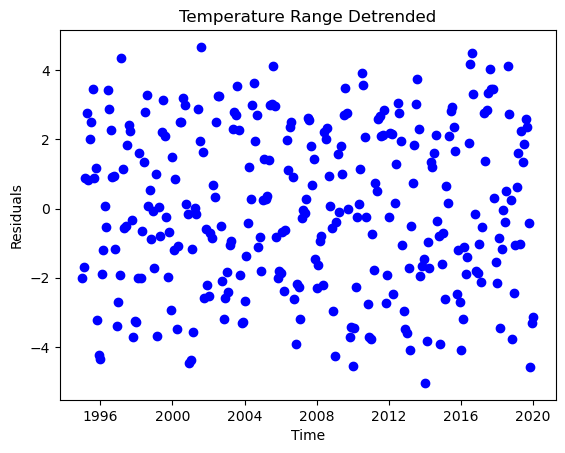

In [50]:
residuals = fit.resid
# Resíduos: detrended time series
plt.subplot(1, 1, 1)
plt.scatter(selected_data['date'], residuals, color='blue')
plt.title("Temperature Range Detrended")
plt.ylabel("Residuals")
plt.xlabel("Time")

plt.show()

                            OLS Regression Results                            
Dep. Variable:                  tdiff   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     11.80
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           0.000675
Time:                        18:56:44   Log-Likelihood:                -679.48
No. Observations:                 301   AIC:                             1363.
Df Residuals:                     299   BIC:                             1370.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.5990      0.706     12.188      0.0

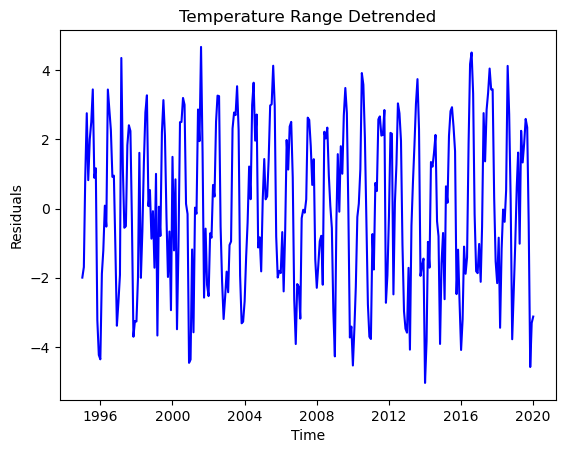

In [51]:
import statsmodels.formula.api as smf 

selected_data['time'] = selected_data['date'].dt.to_period('M').astype(int) 

# fir linear regression model
fit = smf.ols(formula='tdiff ~ time', data=selected_data).fit()
print(fit.summary())

residuals = fit.resid
# Resíduos: detrended time series
plt.subplot(1, 1, 1)
plt.plot(selected_data['date'], residuals, color='blue')
plt.title("Temperature Range Detrended")
plt.ylabel("Residuals")
plt.xlabel("Time")

plt.show()

## Difference Operator

In [52]:
tdiff_series = selected_data['tdiff']
tdiff_diff = tdiff_series.diff(1)
tdiff_diff

date
1995-01-01     NaN
1995-02-01    0.31
1995-03-01    2.59
1995-04-01    1.87
1995-05-01   -1.93
              ... 
2019-09-01   -0.24
2019-10-01   -2.76
2019-11-01   -4.16
2019-12-01    1.28
2020-01-01    0.19
Name: tdiff, Length: 301, dtype: float64

Text(0.5, 0, 'date')

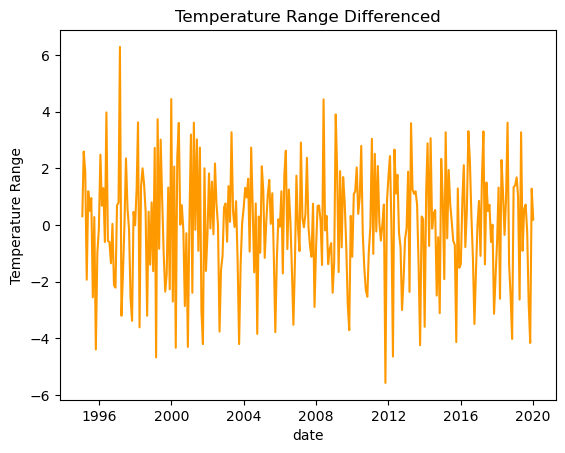

In [53]:
plt.plot(selected_data.index, tdiff_diff, color='#ff9900')
plt.title("Temperature Range Differenced")
plt.ylabel("Temperature Range")
plt.xlabel("date")

In [54]:
diff12 = tdiff_diff.to_frame()
diff12['year_month'] = pd.to_datetime(diff12.index)
diff12

,tdiff,year_month
date,,
1995-01-01,NaN,1995-01-01
1995-02-01,0.31,1995-02-01
1995-03-01,2.59,1995-03-01
1995-04-01,1.87,1995-04-01
1995-05-01,-1.93,1995-05-01
...,...,...
2019-09-01,-0.24,2019-09-01
2019-10-01,-2.76,2019-10-01
2019-11-01,-4.16,2019-11-01


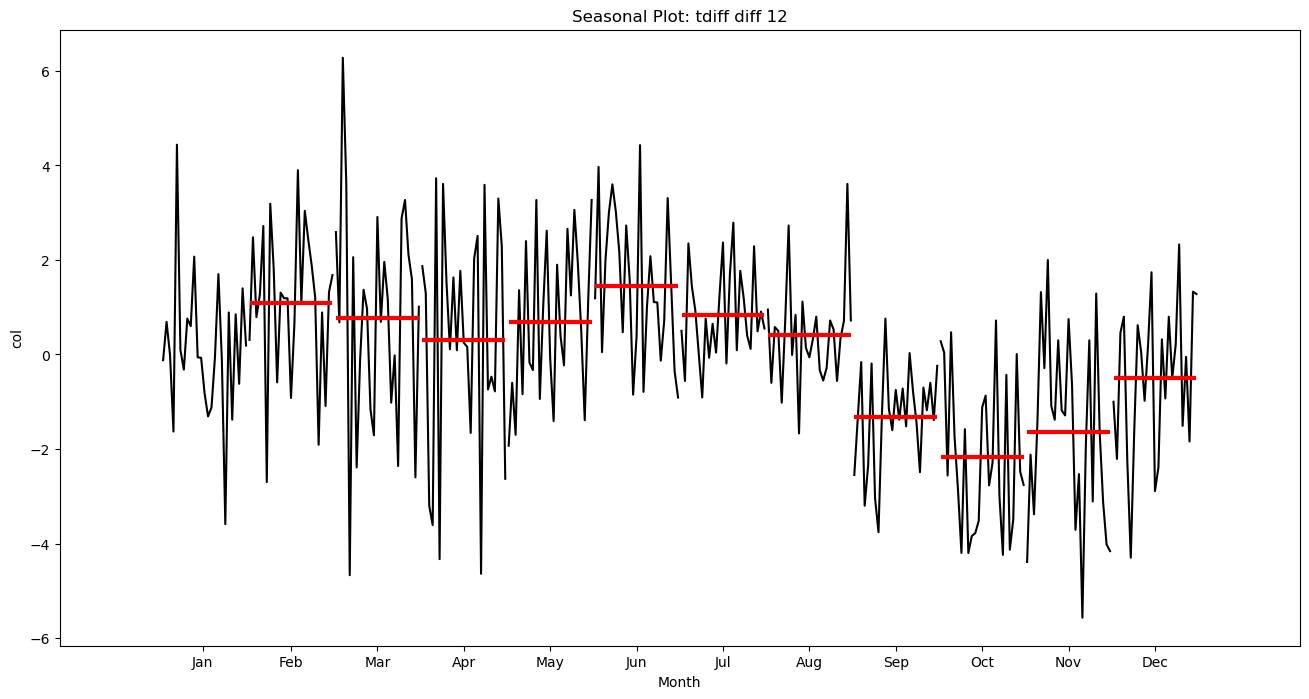

In [55]:
diff12 = tdiff_diff.to_frame()
diff12['year_month'] = pd.to_datetime(diff12.index)

x = diff12[['year_month','tdiff']]
x = x.set_index('year_month')

seasonal_plot(x, 'tdiff', "Seasonal Plot: tdiff diff 12")


## STL Decomposition

In [56]:
# STL with periodic seasonal component
stl_1 = STL(selected_data['tdiff'], seasonal=len(selected_data), robust=True).fit()

# STL with seasonal window of 13
stl_2 = STL(selected_data['tdiff'], seasonal=13, robust=True).fit()

Periodic Season


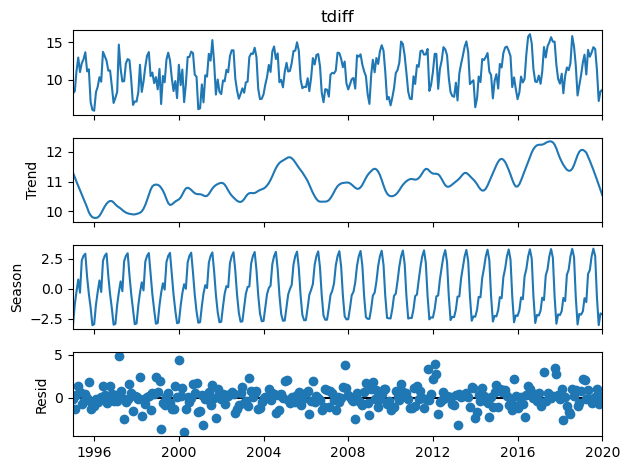

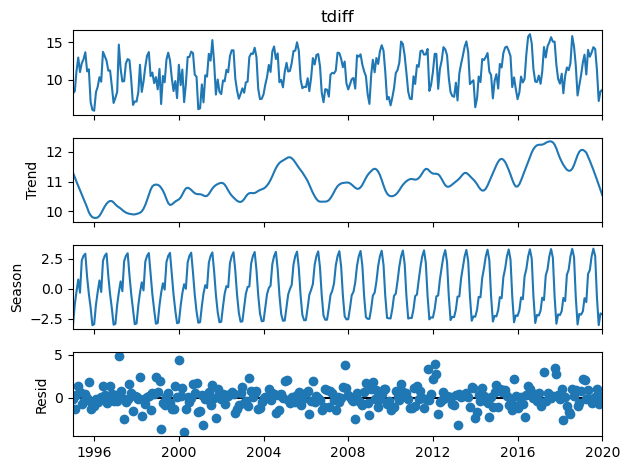

In [57]:
print("Periodic Season")
stl_1.plot()

13 Season


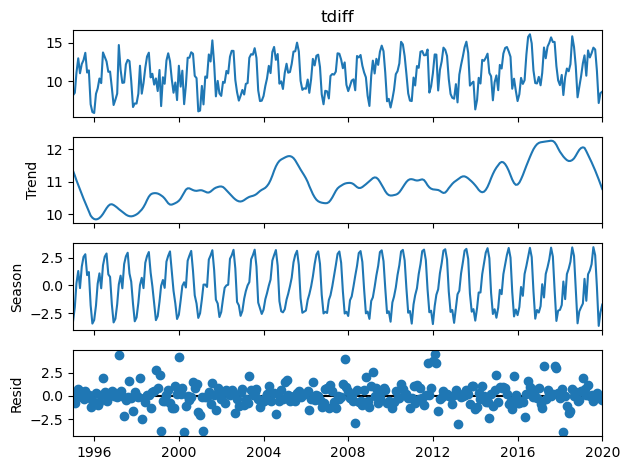

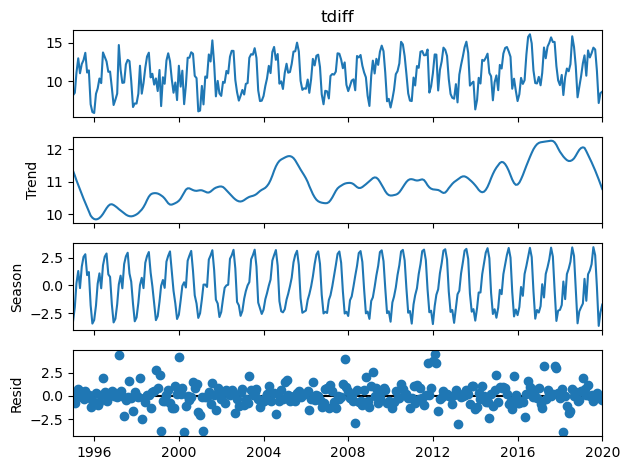

In [58]:
print("13 Season")
stl_2.plot()

In [59]:
from statsmodels.stats.diagnostic import het_arch
print(het_arch(stl_1.resid)) # Not heteroskedascity, null would be homoskedascity, and p-value >> 0.05

(np.float64(7.2810276232815685), np.float64(0.6986744931991759), 0.7185588321572989, 0.7068476103083936)


In [60]:
print(het_arch(stl_1.resid, nlags=12)) 

(np.float64(9.079772650964994), np.float64(0.6961021040009683), 0.7460510194277501, 0.7055757325016481)


## Lag Plots

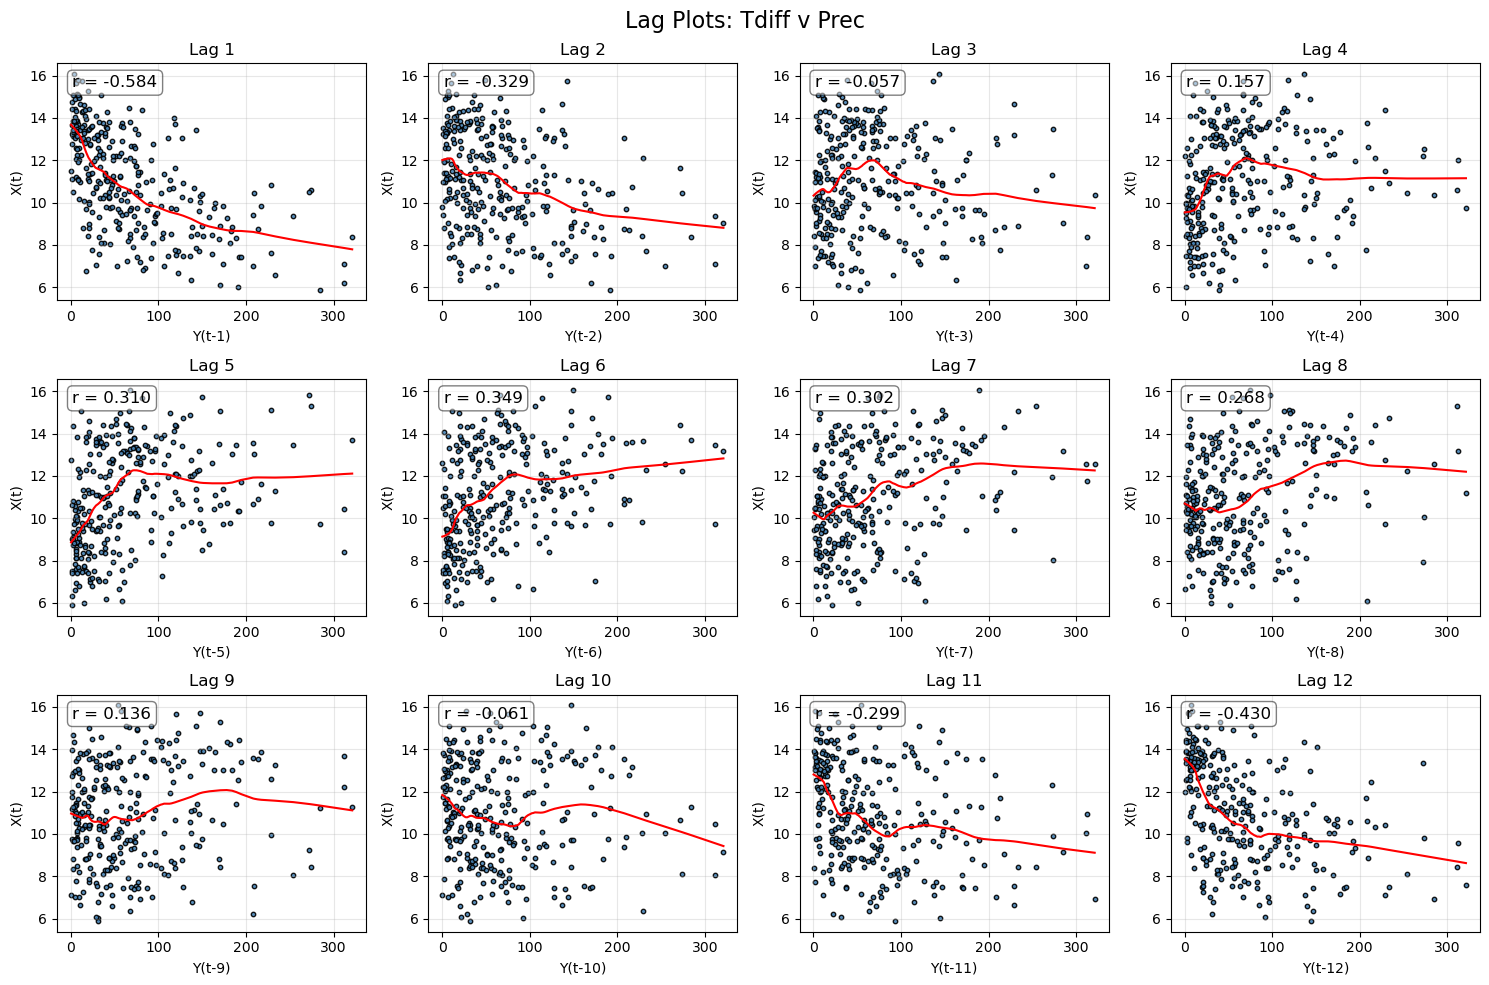

In [61]:
lag_plot_grid(selected_data['tdiff'], ys=selected_data['prec'], title="Lag Plots: Tdiff v Prec")

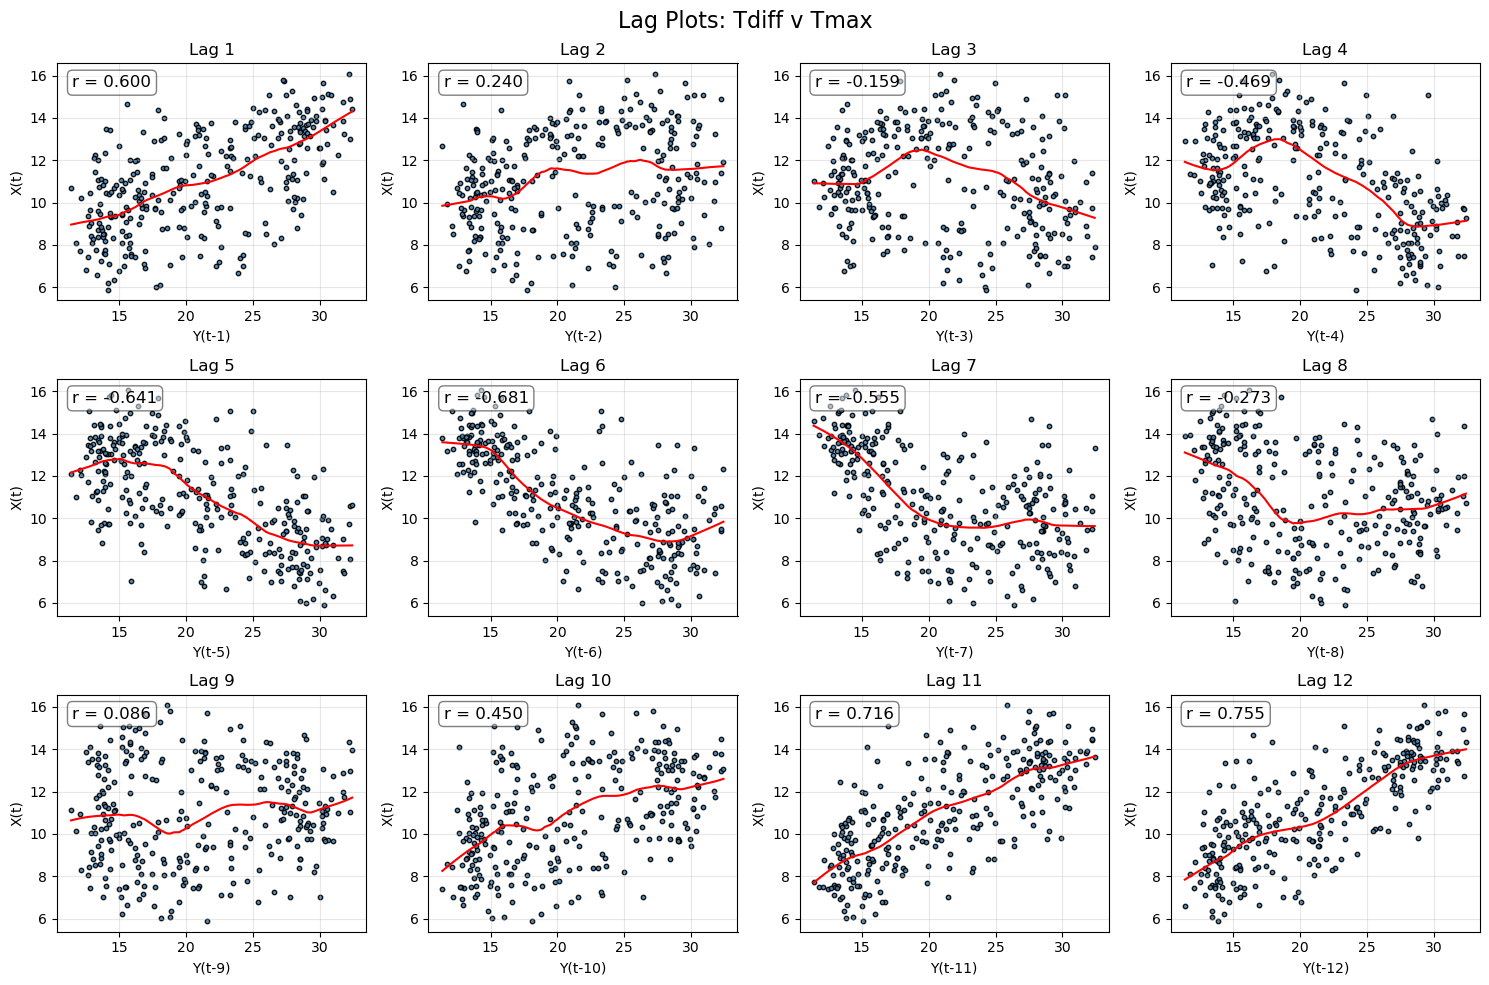

In [62]:
lag_plot_grid(selected_data['tdiff'], ys=selected_data['tmax'], title="Lag Plots: Tdiff v Tmax")

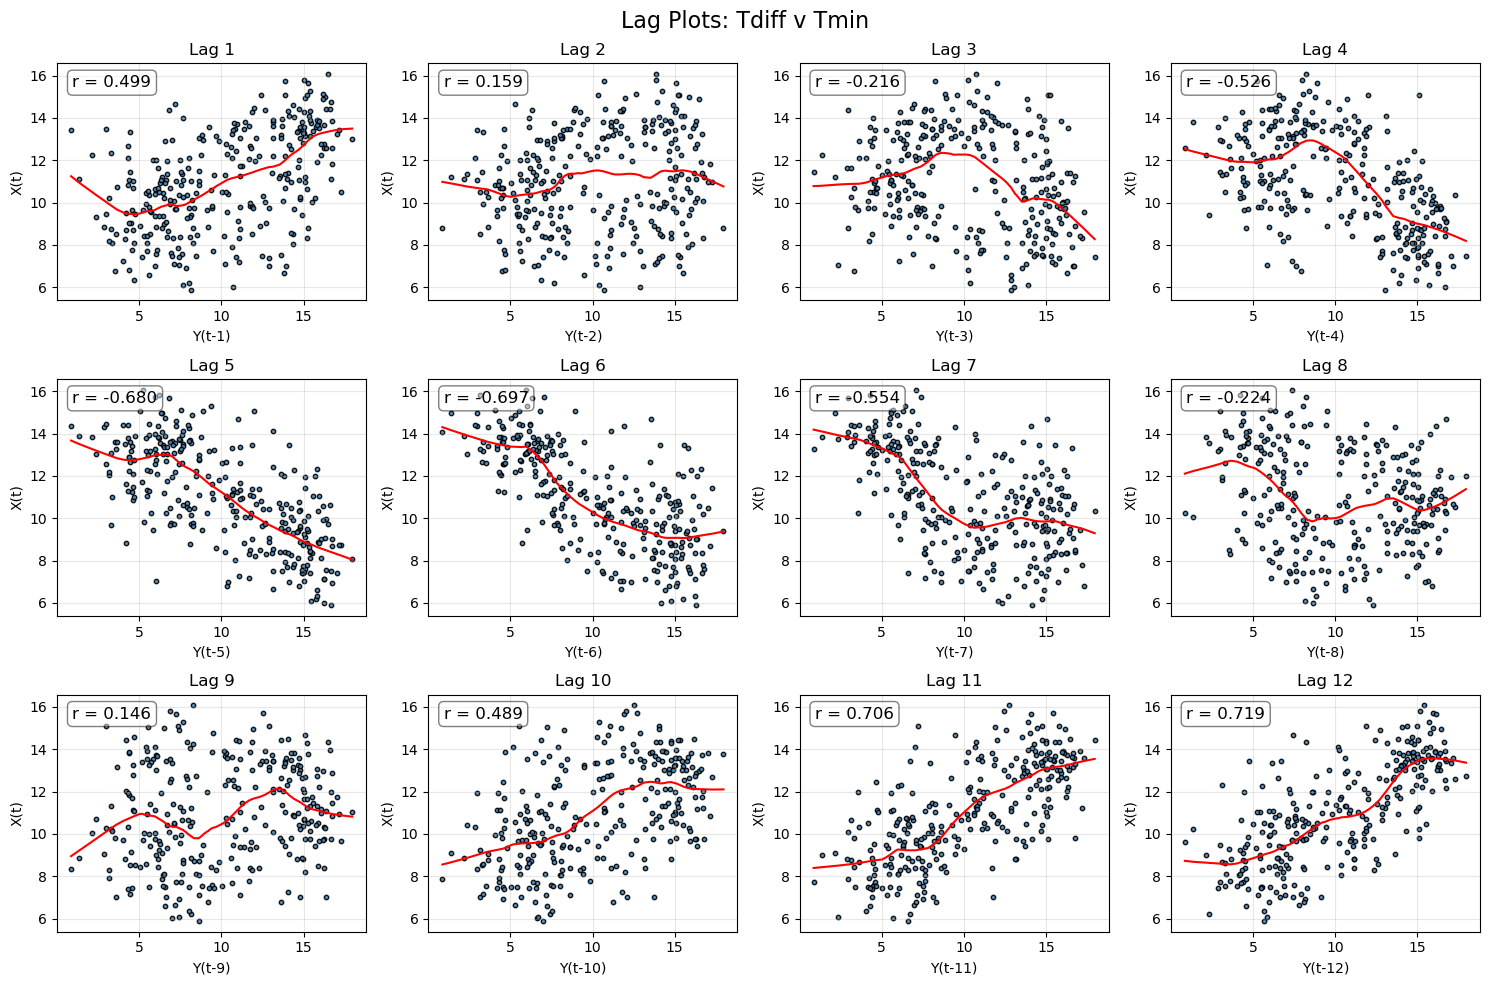

In [63]:
lag_plot_grid(selected_data['tdiff'], ys=selected_data['tmin'], title="Lag Plots: Tdiff v Tmin")

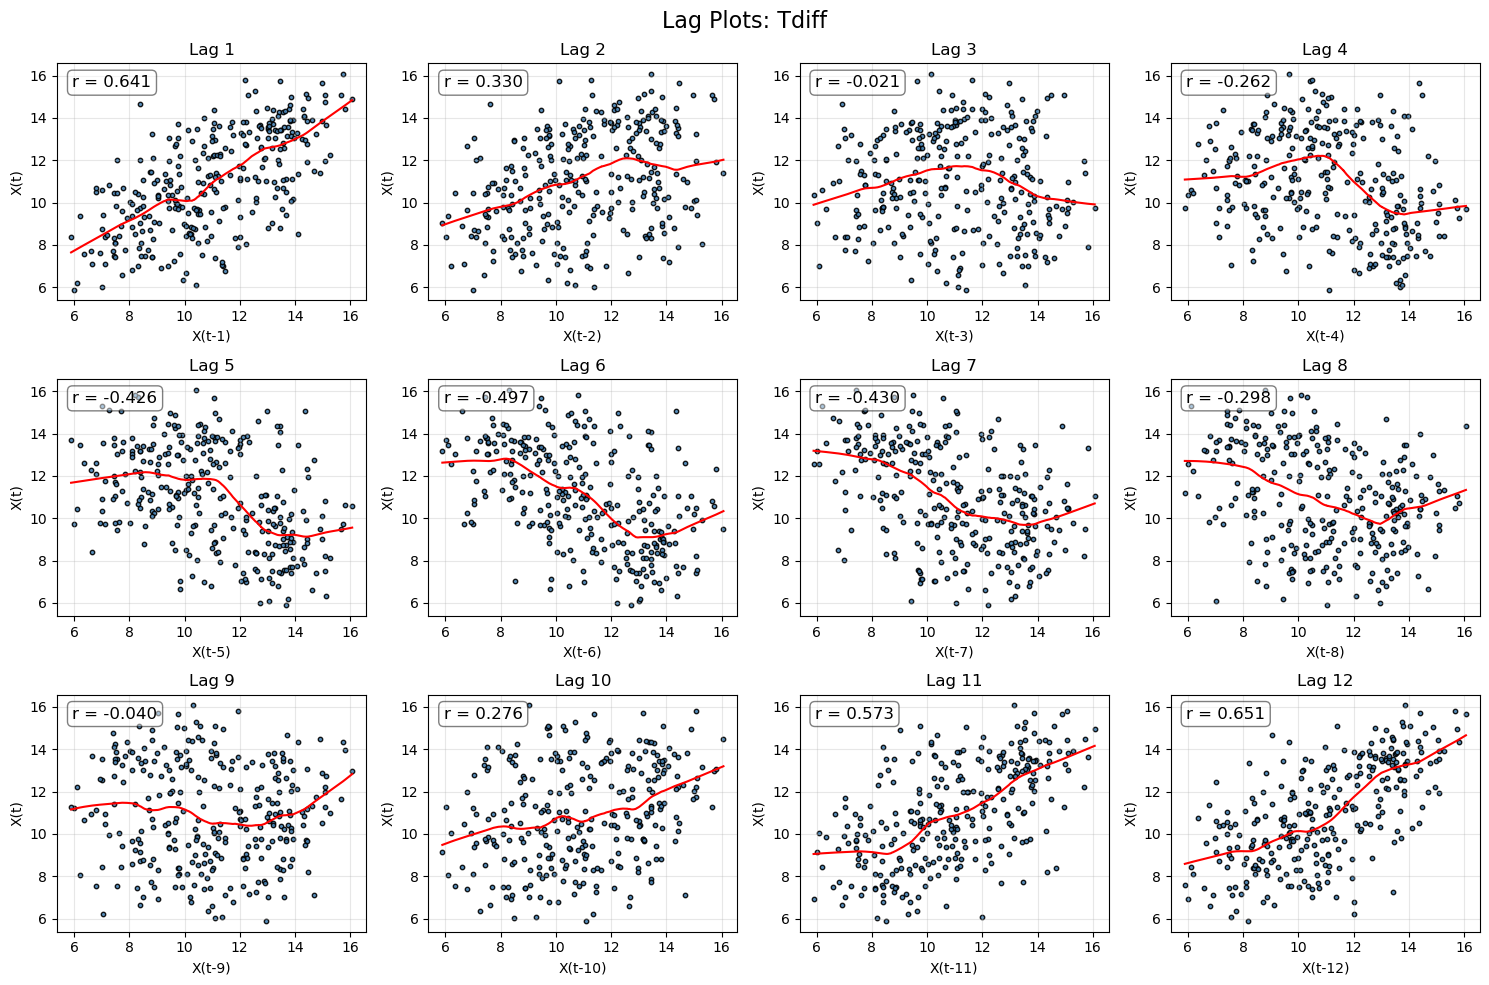

In [64]:
lag_plot_grid(selected_data['tdiff'], title="Lag Plots: Tdiff")

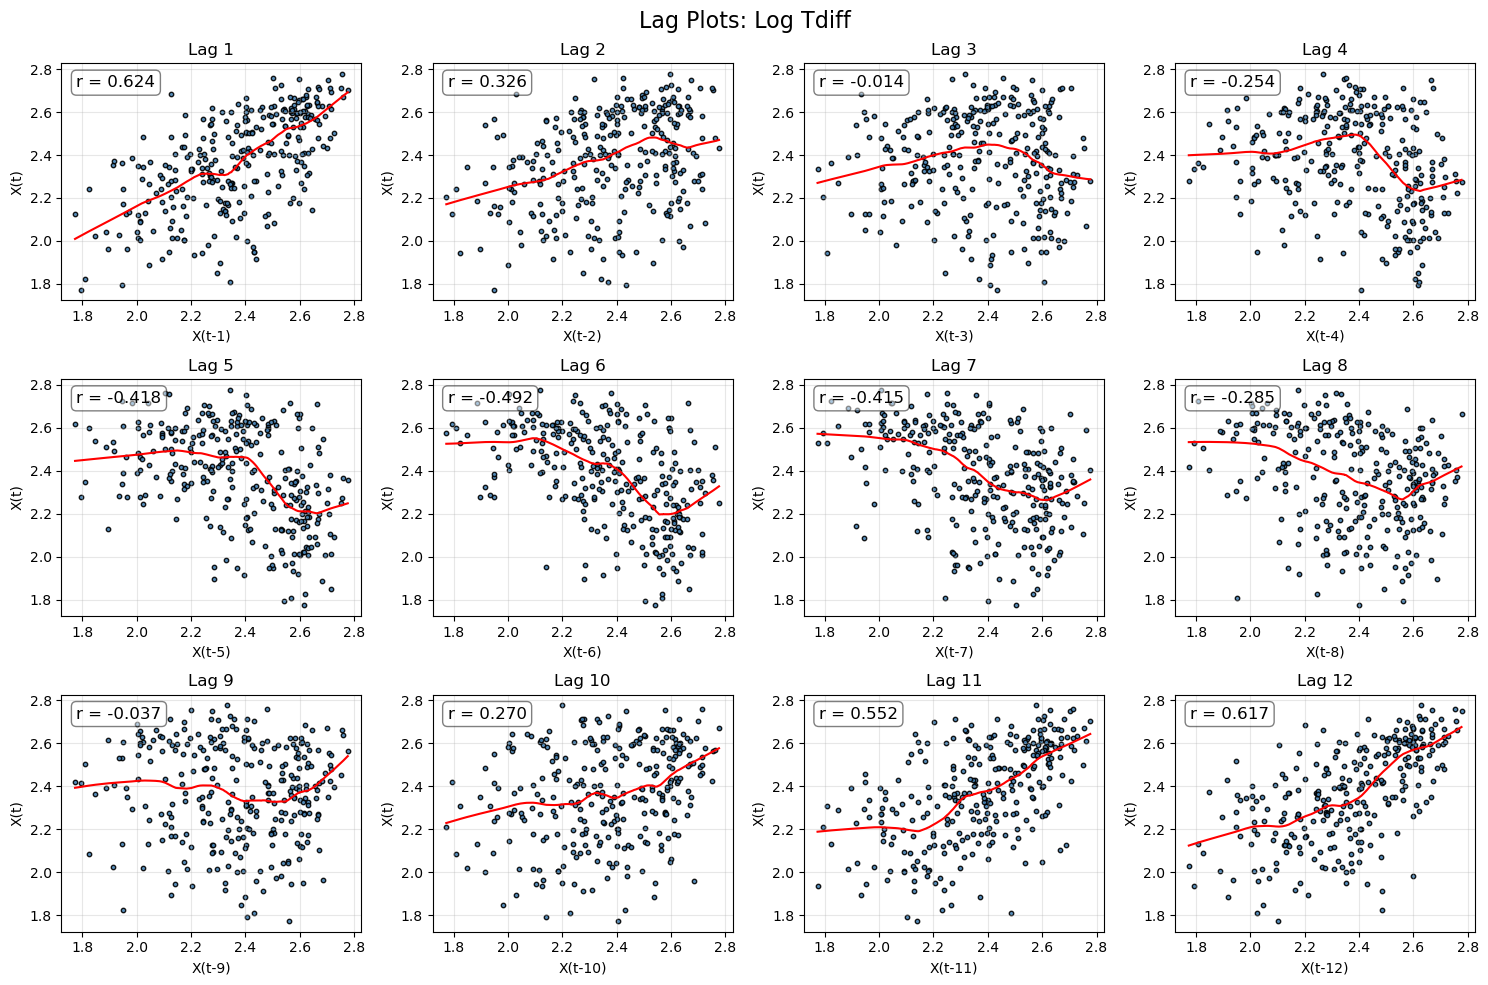

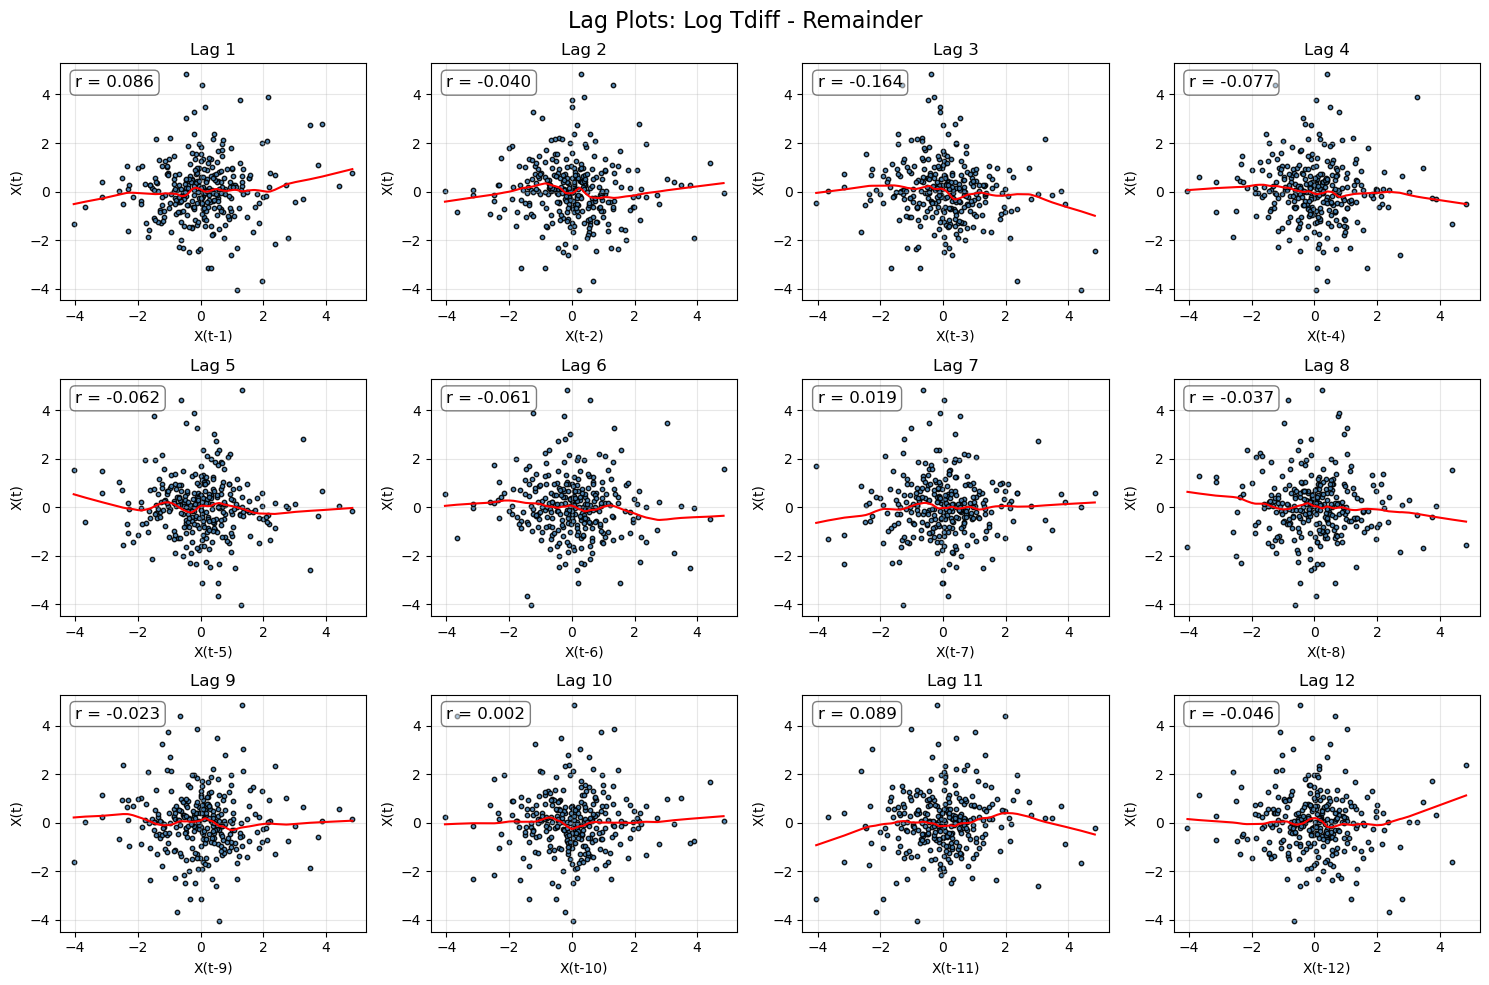

In [65]:
lag_plot_grid(selected_data['log_diff'], title="Lag Plots: Log Tdiff")
lag_plot_grid(stl_1.resid, title="Lag Plots: Log Tdiff - Remainder")

## ACF

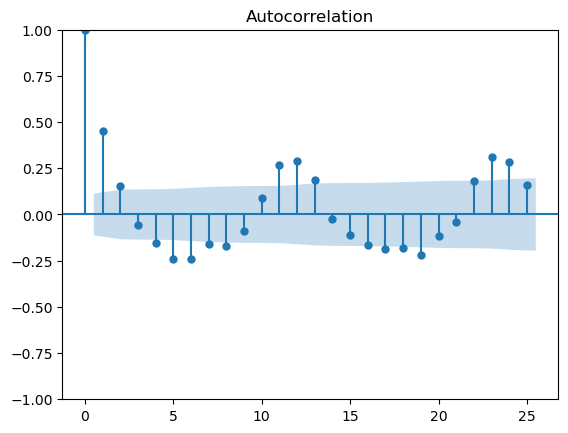

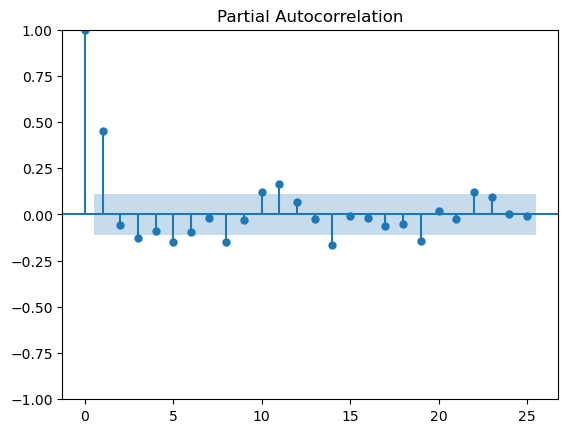

In [66]:
plot_acfs(selected_data, 'prec')

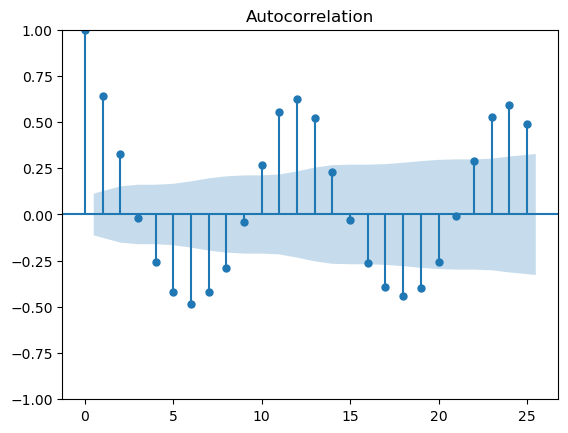

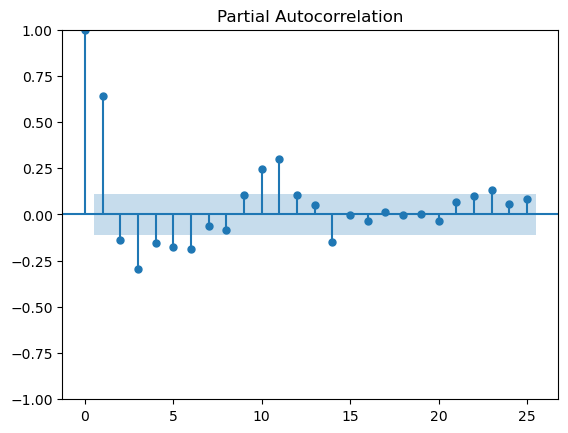

In [67]:
plot_acfs(selected_data, 'tdiff')

## Stationarity

In [68]:
check_stationarity(selected_data['tdiff'])

ADF Statistic: -4.5697573608628215
p-value: 0.0011581547371994896
Stationary
KPSS Statistic: 0.014439485018848917
p-value: 0.1
Stationary


/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


In [69]:
check_stationarity(selected_data['tdiff'].diff().dropna())

ADF Statistic: -8.364419900646396
p-value: 1.0291018978836288e-11
Stationary
KPSS Statistic: 0.01694296956978201
p-value: 0.1
Stationary


/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


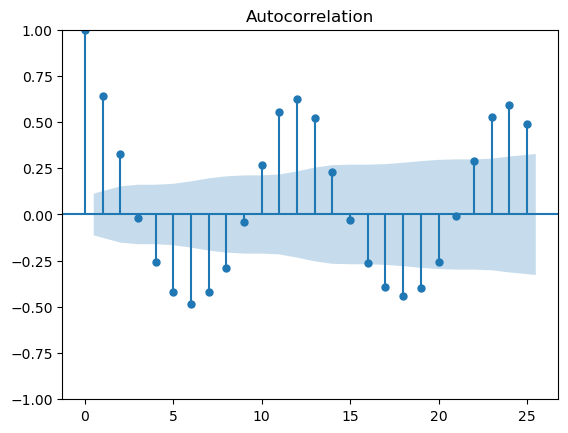

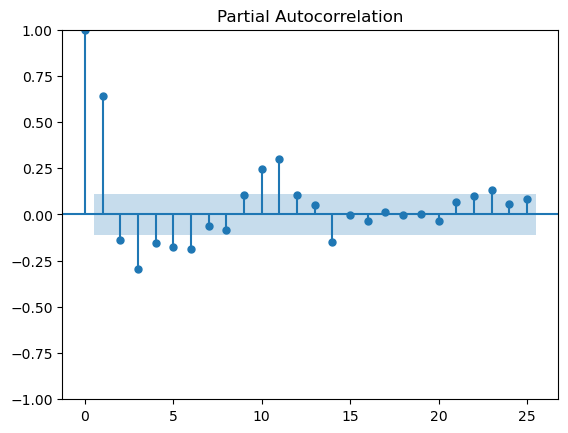

In [70]:
tdiff_diff = selected_data['tdiff']
plot_acf(tdiff_diff)
plot_pacf(tdiff_diff)
plt.show()